In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 6
mpl.rcParams['figure.autolayout'] = True
mpl.rcParams['font.size'] = 15
mpl.rcParams['errorbar.capsize'] = 3
mpl.rcParams['lines.markeredgewidth'] = 1
mpl.rcParams['axes.axisbelow'] = True

In [3]:
def transform_angles(angs): # transforma los ángulos de 0-2pi a 0-pi/2 y luego a grados, para ver lo que nos interesa
    new_angs = angs % np.pi
    new_angs = np.where(new_angs > np.pi/2, np.pi - new_angs,new_angs)
    new_angs = np.degrees(new_angs)
    return new_angs

def load_data(file):
    raw_data = np.loadtxt(f'{file}',delimiter=',')
    total_muons = raw_data[0]
    raw_angles = raw_data[1:]
    angles = transform_angles(raw_angles)
    return angles,total_muons

def calc_res_ang(det_size,det_height,det_delta):
    h = det_size
    l = det_delta
    res_ang = np.degrees(np.arctan(h/l))
    return res_ang

res_ang = calc_res_ang(4.0,1.1,23.6)
bins_res = np.arange(0,100,res_ang*2)
print(res_ang)

9.619727799698852


In [5]:
cos2_pdf = lambda x : np.cos(x)**2/(np.pi/4)
cos2_cdf = lambda x : (np.radians(x) + np.cos(np.radians(x))*np.sin(np.radians(x)))/(2*np.pi/4)
cos_cdf = lambda x : np.sin(np.radians(x))
sin_cdf = lambda x: 1 - np.cos(np.radians(x))

def ecdf(a):
    x, counts = np.unique(a, return_counts=True)
    cusum = np.cumsum(counts)
    return x, cusum / cusum[-1]

from scipy.stats import kstest
from scipy.optimize import curve_fit as cf
cos_n = lambda x,A,n : A*np.cos(np.radians(x))**n
sen_n = lambda x,A,n : A*np.sin(np.radians(x))**n

1.009869858476656 0.014952302343806867
41974 muones detectados de 10^7
p-valor de Kolmogorov (coseno cuadrado): 0.0
p-valor de Kolmogorov (coseno): 0.7613085126279251


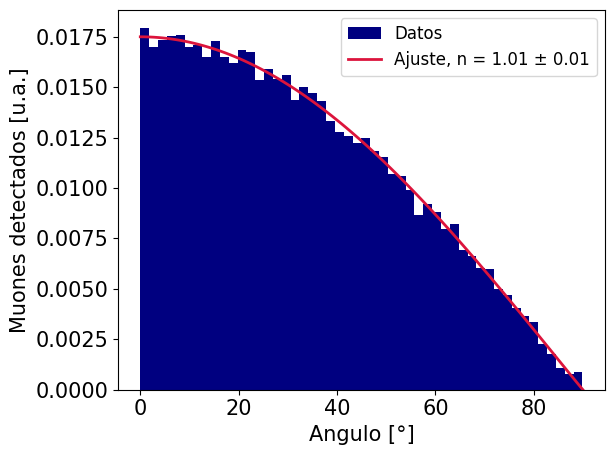

In [53]:
measured_angles,total_muons = load_data('data/data_plano_varios_10M.csv')
measured_angles = measured_angles[:41974]
n,bins,_ = plt.hist(measured_angles,bins=50,density=True,color='navy',label='Datos')
x = np.linspace(0,90,100)
pars,cov = cf(cos_n,bins[:-1]+np.diff(bins)/2,n,p0=[4/np.pi,2])
n_m = pars[1]
err_n_m = np.sqrt(cov[1,1])
print(n_m,err_n_m)
plt.plot(x,cos_n(x,*pars),c='crimson',label=f'Ajuste, n = {np.round(n_m,2)} \u00b1 {np.round(err_n_m,2)}')
plt.legend(fontsize=12)
plt.xlabel('Angulo [°]')
plt.ylabel('Muones detectados [u.a.]')
plt.tight_layout()
print(f'{len(measured_angles)} muones detectados de 10^{int(np.log10(total_muons))}')
print(f'p-valor de Kolmogorov (coseno cuadrado): {kstest(measured_angles,cos2_cdf).pvalue}')
print(f'p-valor de Kolmogorov (coseno): {kstest(measured_angles,cos_cdf).pvalue}')
plt.savefig('plots/sim_plano.png')

1.9486707030976935 0.02733562128807838
39176 muones detectados de 10^6
p-valor de Kolmogorov: 0.07813049910420566


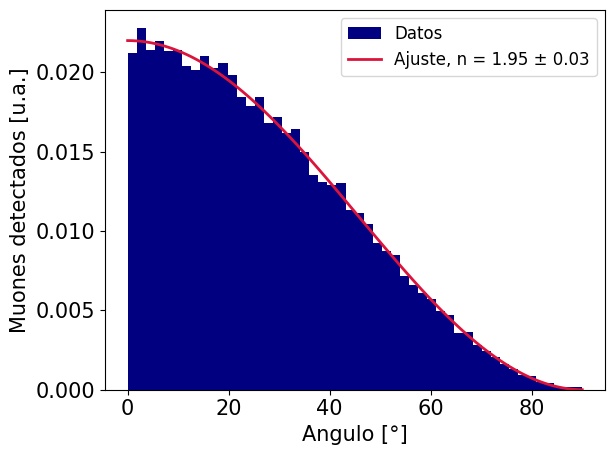

In [52]:
measured_angles,total_muons = load_data('data_plano_varios_cos3.csv')
n,bins,_ = plt.hist(measured_angles,bins=50,density=True,color='navy',label='Datos')
x = np.linspace(0,90,100)
pars,cov = cf(cos_n,bins[:-1]+np.diff(bins)/2,n,p0=[4/np.pi,2])
n_m = pars[1]
err_n_m = np.sqrt(cov[1,1])
print(n_m,err_n_m)
plt.plot(x,cos_n(x,*pars),c='crimson',label=f'Ajuste, n = {np.round(n_m,2)} \u00b1 {np.round(err_n_m,2)}')
plt.legend(fontsize=12)
plt.xlabel('Angulo [°]')
plt.ylabel('Muones detectados [u.a.]')
plt.tight_layout()
print(f'{len(measured_angles)} muones detectados de 10^{int(np.log10(total_muons))}')
kolmogorov = kstest(measured_angles,cos2_cdf)
print(f'p-valor de Kolmogorov: {kolmogorov.pvalue}')
plt.savefig('plots/sim_cos3.png')

43.42904630263077 4.29048770424951
8913 muones detectados de 10^6
p-valor de Kolmogorov: 0.0


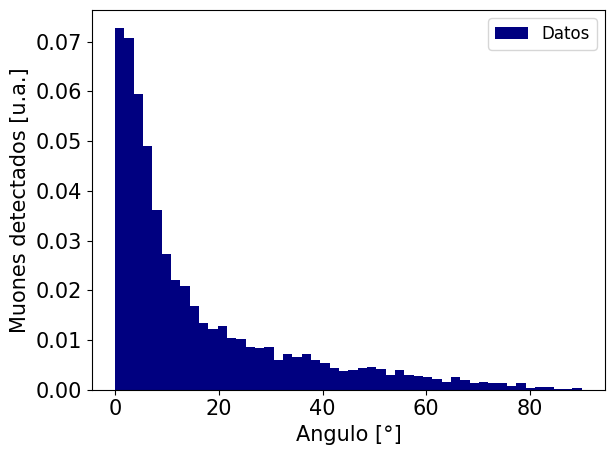

In [8]:
measured_angles,total_muons = load_data('data_plano_varios_phi.csv')
n,bins,_ = plt.hist(measured_angles,bins=50,density=True,color='navy',label='Datos')
x = np.linspace(0,90,100)
pars,cov = cf(cos_n,bins[:-1]+np.diff(bins)/2,n,p0=[4/np.pi,2])
n_m = pars[1]
err_n_m = np.sqrt(cov[1,1])
print(n_m,err_n_m)
#plt.plot(x,cos_n(x,*pars),c='crimson',label=f'Ajuste, n = {np.round(n_m,2)} \u00b1 {np.round(err_n_m,2)}')
plt.legend(fontsize=12)
plt.xlabel('Angulo [°]')
plt.ylabel('Muones detectados [u.a.]')
plt.tight_layout()
print(f'{len(measured_angles)} muones detectados de 10^{int(np.log10(total_muons))}')
kolmogorov = kstest(measured_angles,cos_cdf)
print(f'p-valor de Kolmogorov: {kolmogorov.pvalue}')

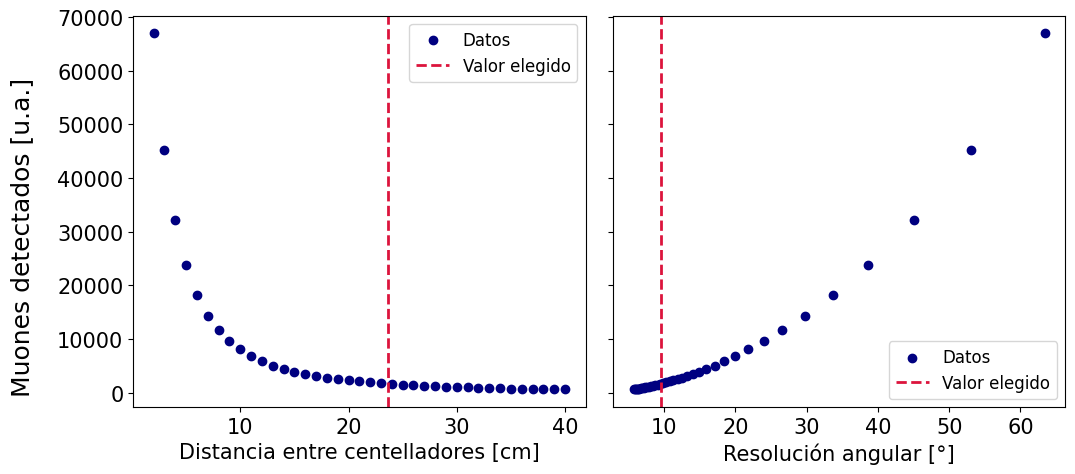

In [54]:
detecteds = np.loadtxt('data_distancias_plano.csv',delimiter=',')

fig,axs = plt.subplots(1,2,figsize=(11,5),sharey=True)

axs[0].scatter(np.arange(2,40+1),detecteds,c='navy',label='Datos')
axs[0].axvline(23.6,color='crimson',ls='--',label='Valor elegido')
fig.supylabel('Muones detectados [u.a.]')
axs[0].set_xlabel('Distancia entre centelladores [cm]')
axs[0].legend(fontsize=12)
#plt.savefig('plots/distancias_muones.svg')
#plt.show()
#plt.scatter(np.arange(2,40+1),np.degrees(np.arctan(4/np.arange(2,40+1))),c='navy',label='Datos')
#plt.axvline(23.6,color='crimson',ls='--',label='Valor elegido')
#plt.ylabel('Resolución angular [°]')
#plt.xlabel('Distancia entre centelladores [cm]')
#plt.legend(fontsize=12)
#plt.tight_layout()
#plt.show()
axs[1].scatter(np.degrees(np.arctan(4/np.arange(2,40+1))),detecteds,c='navy',label='Datos')
axs[1].axvline(np.degrees(np.arctan(4/23.6)),color='crimson',ls='--',label='Valor elegido')
axs[1].set_xlabel('Resolución angular [°]')
axs[1].legend(fontsize=12)
plt.tight_layout()
#plt.savefig('plots/res_ang-muones.svg')

plt.savefig('plots/distancias.png')